# Datathon Passos Mágicos - Fase 5
## Parte 2 - Modelo preditivo de risco de defasagem

Depois da análise exploratória, a ideia aqui é prever se um aluno vai entrar em **risco de
defasagem no ano seguinte**, usando só os indicadores que a Passos Mágicos já coleta todo ano.
Se funcionar bem, a equipe pedagógica consegue priorizar quem precisa de atenção antes da queda
acontecer, em vez de descobrir só depois.

**Como montei o problema:** pra não usar informação do futuro, peguei os indicadores do aluno
num ano (ano N) e usei como alvo o que aconteceu com ele no ano seguinte (ano N+1). Ou seja: os
indicadores de 2022 preveem o risco em 2023, e os de 2023 preveem o risco em 2024.
Considerei "em risco" quem ficou com `defasagem < 0` ou `IAN < 5` no ano seguinte.

In [1]:
import os
import sys

# sobe a partir da pasta atual ate achar a raiz do projeto, pra funcionar tanto
# abrindo o notebook de dentro de notebooks/ quanto da raiz do repositorio
RAIZ = os.getcwd()
while not os.path.isdir(os.path.join(RAIZ, "src")) and os.path.dirname(RAIZ) != RAIZ:
    RAIZ = os.path.dirname(RAIZ)
sys.path.insert(0, os.path.join(RAIZ, "src"))

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from data_cleaning import load_consolidated, build_risk_label

pd.set_option("display.max_columns", 40)

### 1. Montando a base de treino

Primeiro carrego a base consolidada dos 3 anos, marco quem estava em risco em cada ano e
depois junto cada aluno com o registro dele do ano seguinte, pra criar a coluna alvo.

In [2]:
df = load_consolidated()
df["risco"] = build_risk_label(df)

# joga o ano pra trás pra conseguir juntar o aluno com o resultado dele do ano seguinte
proximo_ano = df[["ra", "ano_pesquisa", "risco"]].copy()
proximo_ano["ano_pesquisa"] = proximo_ano["ano_pesquisa"] - 1
proximo_ano = proximo_ano.rename(columns={"risco": "risco_next"})

base = df.merge(proximo_ano, on=["ra", "ano_pesquisa"], how="inner")

print("Total de registros aluno-ano:", len(base))
base["risco_next"].value_counts(normalize=True).round(3)

Total de registros aluno-ano: 1365


risco_next
0    0.506
1    0.494
Name: proportion, dtype: float64

A base ficou bem equilibrada entre as duas classes, então não precisei fazer nenhum
ajuste de balanceamento.

### 2. Preparando as variáveis

Escolhi os indicadores do ano atual como entrada. Preenchi os valores faltantes com a mediana
e transformei gênero e instituição de ensino em colunas 0/1 com `get_dummies`.

In [3]:
FEATURES_NUM = [
    "ian", "ida", "ieg", "iaa", "ips", "ipp", "ipv", "inde",
    "fase_ord", "idade", "ano_ingresso", "pedra_ord", "n_avaliacoes",
]
FEATURES_CAT = ["genero", "instituicao_ensino"]

X = base[FEATURES_NUM + FEATURES_CAT].copy()
X[FEATURES_NUM] = X[FEATURES_NUM].fillna(X[FEATURES_NUM].median())
X = pd.get_dummies(X, columns=FEATURES_CAT)

y = base["risco_next"]

print("Variáveis usadas:", X.shape[1])
X.head()

Variáveis usadas: 26


,ian,ida,ieg,iaa,ips,ipp,ipv,inde,fase_ord,idade,ano_ingresso,pedra_ord,n_avaliacoes,genero_Feminino,genero_Masculino,instituicao_ensino_Concluiu o 3º EM,instituicao_ensino_Escola JP II,instituicao_ensino_Escola Pública,instituicao_ensino_Nenhuma das opções acima,instituicao_ensino_Privada,instituicao_ensino_Privada *Parcerias com Bolsa 100%,instituicao_ensino_Privada - Pagamento por *Empresa Parceira,instituicao_ensino_Privada - Programa de Apadrinhamento,instituicao_ensino_Privada - Programa de apadrinhamento,instituicao_ensino_Pública,instituicao_ensino_Rede Decisão
0,5.0,4.0,4.1,8.3,5.6,7.708333,7.278,5.783,7.0,19.0,2016,1.0,4.0,True,False,False,False,True,False,False,False,False,False,False,False,False
1,10.0,6.8,5.2,8.8,6.3,7.708333,6.778,7.055,7.0,17.0,2017,3.0,4.0,True,False,False,False,False,False,False,False,False,False,False,False,True
2,10.0,5.2,8.6,7.9,5.6,7.708333,7.389,7.427,7.0,17.0,2016,3.0,4.0,True,False,False,False,False,False,False,False,False,False,False,False,True
3,5.0,3.3,4.5,7.9,7.5,7.708333,7.222,5.848,7.0,18.0,2021,1.0,4.0,True,False,False,False,True,False,False,False,False,False,False,False,False
4,5.0,7.6,8.4,0.0,7.5,7.708333,7.667,6.818,7.0,18.0,2017,2.0,4.0,False,True,False,False,False,False,False,False,False,False,False,False,True


### 3. Separando treino e teste

Separei 20% dos dados pra teste, mantendo a mesma proporção de alunos em risco nos dois
conjuntos (`stratify`).

In [4]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Treino:", X_treino.shape, "| Teste:", X_teste.shape)

Treino: (1092, 26) | Teste: (273, 26)


### 4. Treinando os modelos

Testei dois modelos pra comparar: uma regressão logística (mais simples, serve de referência)
e um Random Forest.

In [5]:
regressao = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
regressao.fit(X_treino, y_treino)

floresta = RandomForestClassifier(n_estimators=200, random_state=42)
floresta.fit(X_treino, y_treino)

print("Regressão logística:", round(accuracy_score(y_teste, regressao.predict(X_teste)), 3))
print("Random Forest:      ", round(accuracy_score(y_teste, floresta.predict(X_teste)), 3))

Regressão logística: 0.769
Random Forest:       0.802


### 5. Avaliando o modelo escolhido

In [6]:
modelo = floresta
y_pred = modelo.predict(X_teste)

print(classification_report(y_teste, y_pred, target_names=["Sem risco", "Em risco"]))

              precision    recall  f1-score   support

   Sem risco       0.82      0.78      0.80       138
    Em risco       0.78      0.83      0.81       135

    accuracy                           0.80       273
   macro avg       0.80      0.80      0.80       273
weighted avg       0.80      0.80      0.80       273



In [7]:
matriz = pd.DataFrame(
    confusion_matrix(y_teste, y_pred),
    index=["Real: sem risco", "Real: em risco"],
    columns=["Previsto: sem risco", "Previsto: em risco"],
)
matriz

,Previsto: sem risco,Previsto: em risco
Real: sem risco,107,31
Real: em risco,23,112


### 6. Quais indicadores mais pesam

O Random Forest já devolve a importância de cada variável, então dá pra ver quais indicadores
o modelo mais usa pra decidir.

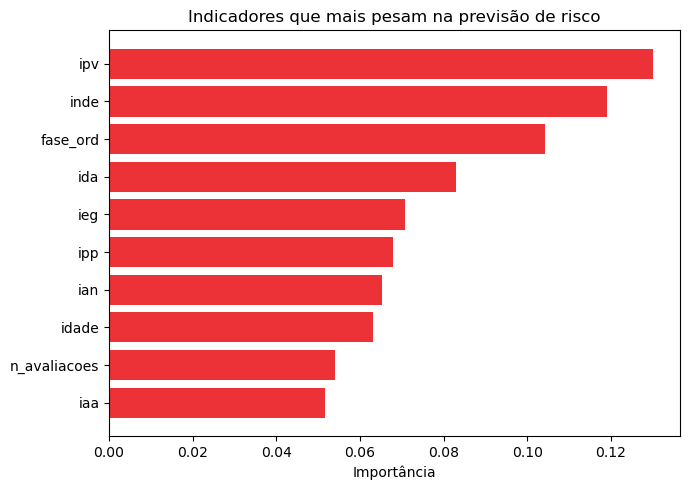

In [8]:
importancias = pd.Series(modelo.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(importancias.index[::-1], importancias.values[::-1], color="#ED3237")
ax.set_xlabel("Importância")
ax.set_title("Indicadores que mais pesam na previsão de risco")
plt.tight_layout()
plt.savefig(os.path.join(RAIZ, "presentation", "assets", "11_pesos_modelo.png"), bbox_inches="tight")
plt.show()

### 7. Salvando o modelo pra usar no app

Salvo o modelo junto com a lista de colunas, porque o app precisa montar as mesmas colunas
na hora de fazer uma previsão nova.

In [9]:
import pickle

with open(os.path.join(RAIZ, "streamlit", "risk_model.pkl"), "wb") as f:
    pickle.dump({"modelo": modelo, "colunas": list(X.columns)}, f)

print("Modelo salvo em streamlit/risk_model.pkl")

Modelo salvo em streamlit/risk_model.pkl


### Conclusão

O modelo consegue prever com uma acurácia razoável se um aluno vai entrar em risco de defasagem
no ano seguinte, usando só os indicadores que a Passos Mágicos já coleta. Não é um modelo
perfeito, mas serve como um sinal de alerta pra equipe pedagógica priorizar acompanhamento antes
da queda acontecer. O modelo treinado é usado no app (`streamlit/app.py`) pra simular o risco de
um aluno a partir dos indicadores mais recentes dele.